# Backtesting — Asian Paints Hybrid Options Model (V3)

**Pipeline:** Raw NSE options CSV → preprocessing → feature engineering → HybridNetV3 inference → evaluation vs actual Settle Price

Drop any NSE-format options file in `OPTIONS_FILE` and run all cells.

## 0 — Config & Imports

In [174]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import pickle
from scipy.stats import norm

# ── File paths — only change these
OPTIONS_FILE  = '../../data/processed/backtest_dataset.csv'
VIX_FILE      = '../../data/raw/market/VIX_data.csv'
STOCK_FILE    = '../../data/raw/market/spot_price.csv'  # for calculating rolling sigma
WARMUP_FILE   = '../../data/raw/market/spot_price.csv'  # used to seed rolling sigma
MODEL_FILE    = '../../artifacts/hybrid_model_v3.pt'
SCALER_FILE   = '../../artifacts/scaler.pkl'
OUTPUT_CSV    = '../../outputs/backtest_results.csv'

# ── Constants — must match training exactly
RISK_FREE_RATE = 0.067
DIVIDEND_YIELD = 0.01
EPS            = 1e-6

FEATURES = [
    'log_moneyness', 'T', 'sqrt_T',
    'sigma', 'sigma_sqrt_T', 'vix', 'vol_ma',
    'delta', 'gamma', 'vega', 'theta',
    'vix_ratio', 'time_vol', 'vega_scaled'
]

SIGMA_INDEX = FEATURES.index('sigma')   # = 3

# ── Filters — must match training
MIN_PRICE       = 5.0
MIN_T, MAX_T    = 0.05, 0.5
MIN_M, MAX_M    = -0.3, 0.3

print('✓ Config ready')
print(f'  sigma_index = {SIGMA_INDEX}')
print(f'  Features    = {len(FEATURES)}')

✓ Config ready
  sigma_index = 3
  Features    = 14


## 1 — Model Definition (HybridNetV3)

In [175]:
class HybridNetV3(nn.Module):
    def __init__(self, input_dim, sigma_index):
        super().__init__()
        
        self.sigma_index = sigma_index
        
        self.shared = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),

            nn.Linear(256, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),

            nn.Linear(128, 64),
            nn.ReLU(),
        )
        
        self.log_error_head = nn.Linear(64, 1)
        self.alpha_head = nn.Linear(64, 1)
        
    def forward(self, x, bs):
        h = self.shared(x)
        
        log_error = self.log_error_head(h).squeeze()

        sigma = x[:, self.sigma_index]
        sigma_scaled = torch.sigmoid(sigma)
        log_error = log_error / (1 + 0.5 * sigma_scaled)

        alpha_raw = self.alpha_head(h).squeeze()
        alpha = torch.sigmoid(alpha_raw - 0.5 * log_error)

        ml_price = bs * torch.exp(log_error)
        hybrid = alpha * bs + (1 - alpha) * ml_price

        return hybrid, alpha, log_error


def load_model(model_path, scaler_path):
    with open(scaler_path, 'rb') as f:
        scaler = pickle.load(f)

    model = HybridNetV3(input_dim=len(FEATURES), sigma_index=SIGMA_INDEX)
    state = torch.load(model_path, map_location='cpu')
    model.load_state_dict(state)
    model.eval()
    print(f'✓ Model loaded from {model_path}')
    print(f'✓ Scaler loaded  ({scaler.n_features_in_} features)')
    return model, scaler


model, scaler = load_model(MODEL_FILE, SCALER_FILE)

✓ Model loaded from hybrid_model_v3.pt
✓ Scaler loaded  (14 features)


## 2 — Helper Functions

In [176]:
def bs_call(S, K, T, r, sigma, q=DIVIDEND_YIELD):
    """Scalar Black-Scholes — safe, used row-wise if needed."""
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return np.nan
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)


def bs_call_vec(S, K, T, r, sigma, q=DIVIDEND_YIELD):
    """Vectorised Black-Scholes — fast, used on whole columns."""
    S, K, T, r, sigma = (np.asarray(a, dtype=float) for a in [S, K, T, r, sigma])
    valid = (T > 0) & (sigma > 0) & (S > 0) & (K > 0)
    price = np.full(len(S), np.nan)
    sv, kv, tv, rv, sigv = S[valid], K[valid], T[valid], r[valid], sigma[valid]
    d1 = (np.log(sv/kv) + (rv - q + 0.5*sigv**2)*tv) / (sigv*np.sqrt(tv))
    d2 = d1 - sigv*np.sqrt(tv)
    price[valid] = sv*np.exp(-q*tv)*norm.cdf(d1) - kv*np.exp(-rv*tv)*norm.cdf(d2)
    return price


def compute_greeks(df):
    S     = df['S'].values
    K     = df['K'].values
    T     = np.maximum(df['T'].values, EPS)
    r     = df['r'].values
    sigma = np.maximum(df['sigma'].values, EPS)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    df = df.copy()
    df['delta'] = norm.cdf(d1)
    df['gamma'] = norm.pdf(d1) / (S*sigma*np.sqrt(T) + EPS)
    df['vega']  = S*norm.pdf(d1)*np.sqrt(T)
    df['theta'] = (-(S*norm.pdf(d1)*sigma)/(2*np.sqrt(T))
                   - r*K*np.exp(-r*T)*norm.cdf(d2))
    return df


print('✓ Helper functions defined')

✓ Helper functions defined


## 3 — Load & Merge Raw Data

In [177]:
# ── Load options file
df = pd.read_csv(OPTIONS_FILE)
df.columns = [c.strip() for c in df.columns]   # NSE files have trailing spaces

df['Date']   = pd.to_datetime(df['trade_date'],   dayfirst=True, format='mixed', errors='coerce')
df['Expiry'] = pd.to_datetime(df['expiry'], dayfirst=True, format='mixed', errors='coerce')
df['T']      = (df['Expiry'] - df['Date']).dt.days / 365.0
df = df[df['T'] > 0].sort_values('Date').reset_index(drop=True)

df = df.rename(columns={
    'spot_close': 'S',
    'strike':     'K',
    'settle_price': 'Market_Price',
})
df['r'] = RISK_FREE_RATE
for col in ['S', 'K', 'Market_Price']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Loaded {len(df):,} rows')
print(f'Date range : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Expiries   : {sorted(df["Expiry"].dt.date.unique())}')
print(f'Strike     : {df["K"].min():.0f} – {df["K"].max():.0f}')
print(f'Market_Price nulls: {df["Market_Price"].isna().sum()}')

Loaded 404,270 rows
Date range : 2019-01-01 → 2024-07-05
Expiries   : [datetime.date(2019, 1, 31), datetime.date(2019, 2, 28), datetime.date(2019, 3, 28), datetime.date(2019, 4, 25), datetime.date(2019, 5, 30), datetime.date(2019, 6, 27), datetime.date(2019, 7, 25), datetime.date(2019, 8, 29), datetime.date(2019, 9, 26), datetime.date(2019, 10, 31), datetime.date(2019, 11, 28), datetime.date(2019, 12, 26), datetime.date(2020, 1, 30), datetime.date(2020, 2, 27), datetime.date(2020, 3, 26), datetime.date(2020, 4, 30), datetime.date(2020, 5, 28), datetime.date(2020, 6, 25), datetime.date(2020, 7, 30), datetime.date(2020, 8, 27), datetime.date(2020, 9, 24), datetime.date(2020, 10, 29), datetime.date(2020, 11, 26), datetime.date(2020, 12, 31), datetime.date(2021, 1, 28), datetime.date(2021, 2, 25), datetime.date(2021, 3, 25), datetime.date(2021, 4, 29), datetime.date(2021, 5, 27), datetime.date(2021, 6, 24), datetime.date(2021, 7, 29), datetime.date(2021, 8, 26), datetime.date(2021, 9, 30),

In [178]:
df = df[(df['option_type'] == 'CE') & (df['Date'] >= pd.to_datetime('2021-01-01'))]

In [179]:
df.head()

,INSTRUMENT,symbol,expiry,K,option_type,open,high,low,close,Market_Price,...,oi_change,TIMESTAMP,UNNAMED: 15,trade_date,S,moneyness,Date,Expiry,T,r
118997,OPTSTK,ASIANPAINT,25-Mar-2021,1980.0,CE,0.0,0.0,0.0,806.15,815.90,...,0.0,01-JAN-2021,NaN,2021-01-01,2656.677002,0.745292,2021-01-01,2021-03-25,0.227397,0.067
118999,OPTSTK,ASIANPAINT,25-Mar-2021,1960.0,CE,0.0,0.0,0.0,825.30,835.45,...,0.0,01-JAN-2021,NaN,2021-01-01,2656.677002,0.737764,2021-01-01,2021-03-25,0.227397,0.067
119025,OPTSTK,ASIANPAINT,25-Feb-2021,2980.0,CE,0.0,0.0,0.0,12.95,67.10,...,0.0,01-JAN-2021,NaN,2021-01-01,2656.677002,1.121702,2021-01-01,2021-02-25,0.150685,0.067
119027,OPTSTK,ASIANPAINT,25-Feb-2021,3160.0,CE,0.0,0.0,0.0,18.15,30.20,...,0.0,01-JAN-2021,NaN,2021-01-01,2656.677002,1.189456,2021-01-01,2021-02-25,0.150685,0.067
119028,OPTSTK,ASIANPAINT,25-Feb-2021,3140.0,CE,0.0,0.0,0.0,19.50,33.20,...,0.0,01-JAN-2021,NaN,2021-01-01,2656.677002,1.181928,2021-01-01,2021-02-25,0.150685,0.067


In [180]:
spot=pd.read_csv(WARMUP_FILE)
spot['Date'] = pd.to_datetime(spot['Date'], dayfirst=True, format='mixed', errors='coerce')
spot = spot.sort_values('Date').reset_index(drop=True)


In [181]:
spot['returns']= np.log(spot['close'] / spot['close'].shift(1))
spot['sigma'] = spot['returns'].rolling(window=20).std() * np.sqrt(252)

df = pd.merge(df, spot[['Date','sigma']], on='Date', how='left')

In [182]:
# # ── Rolling 20-day realised sigma — seeded from historical data
# # Without warmup, the first ~20 trading days have sigma=0 → BS price = NaN.
# # Fix: prepend last 30 days of underlying from the training dataset.

# try:
#     # 1. Load and strip column names immediately
#     hist = pd.read_csv(WARMUP_FILE)
#     hist.columns = [c.strip() for c in hist.columns]
    
#     # 2. Use 'mixed' format to handle the variety in NSE date strings
#     hist['Date'] = pd.to_datetime(hist['Date'], dayfirst=True, format='mixed', errors='coerce')
    
#     # 3. Identify the Underlying Value column (handles 'S' or 'Underlying Value')
#     uv_col = 'Underlying Value' if 'Underlying Value' in hist.columns else 'S'
#     hist[uv_col] = pd.to_numeric(hist[uv_col], errors='coerce')
    
#     # 4. Filter for historical dates and get the last 30 trading sessions
#     warmup = (
#         hist[hist['Date'] < df['Date'].min()]
#         .rename(columns={uv_col: 'S'})
#         .drop_duplicates('Date')
#         .sort_values('Date')
#         .tail(30)[['Date', 'S']]
#     )
    
#     # Drop any rows where S became NaN due to '---' values
#     warmup = warmup.dropna(subset=['S'])
    
#     print(f'✓ Sigma warmup: {len(warmup)} days seeded from {WARMUP_FILE}')
# except Exception as e:
#     warmup = pd.DataFrame(columns=['Date', 'S'])
#     print(f'⚠️ Warmup warning: {e}. Early sigma may be flat.')

# daily_spot = df[['Date', 'S']].drop_duplicates('Date').sort_values('Date').copy()
# combined   = (
#     pd.concat([warmup[['Date', 'S']], daily_spot], ignore_index=True)
#     .drop_duplicates('Date').sort_values('Date')
# )
# combined['returns'] = np.log(combined['S'] / combined['S'].shift(1))
# combined['sigma']   = combined['returns'].rolling(window=20, min_periods=5).std() * np.sqrt(252)

# sigma_map = combined[combined['Date'].isin(daily_spot['Date'])][['Date', 'sigma']]

# df['Date'] = df['Date'].dt.tz_localize(None)
# sigma_map['Date'] = sigma_map['Date'].dt.tz_localize(None)
# df = df.merge(sigma_map, on='Date', how='left')
# df['sigma'] = df['sigma'].ffill().bfill()

# print(f'Sigma  — min: {df["sigma"].min():.4f}  max: {df["sigma"].max():.4f}  nulls: {df["sigma"].isna().sum()}')

In [183]:
df['sigma'] = df['sigma'].fillna(method='ffill').fillna(method='bfill')

In [184]:
df

,INSTRUMENT,symbol,expiry,K,option_type,open,high,low,close,Market_Price,...,TIMESTAMP,UNNAMED: 15,trade_date,S,moneyness,Date,Expiry,T,r,sigma
0,OPTSTK,ASIANPAINT,25-Mar-2021,1980.0,CE,0.0,0.0,0.0,806.15,815.90,...,01-JAN-2021,NaN,2021-01-01,2656.677002,0.745292,2021-01-01,2021-03-25,0.227397,0.067,0.194369
1,OPTSTK,ASIANPAINT,25-Mar-2021,1960.0,CE,0.0,0.0,0.0,825.30,835.45,...,01-JAN-2021,NaN,2021-01-01,2656.677002,0.737764,2021-01-01,2021-03-25,0.227397,0.067,0.194369
2,OPTSTK,ASIANPAINT,25-Feb-2021,2980.0,CE,0.0,0.0,0.0,12.95,67.10,...,01-JAN-2021,NaN,2021-01-01,2656.677002,1.121702,2021-01-01,2021-02-25,0.150685,0.067,0.194369
3,OPTSTK,ASIANPAINT,25-Feb-2021,3160.0,CE,0.0,0.0,0.0,18.15,30.20,...,01-JAN-2021,NaN,2021-01-01,2656.677002,1.189456,2021-01-01,2021-02-25,0.150685,0.067,0.194369
4,OPTSTK,ASIANPAINT,25-Feb-2021,3140.0,CE,0.0,0.0,0.0,19.50,33.20,...,01-JAN-2021,NaN,2021-01-01,2656.677002,1.181928,2021-01-01,2021-02-25,0.150685,0.067,0.194369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142660,OPTSTK,ASIANPAINT,29-Aug-2024,2740.0,CE,0.0,0.0,0.0,219.20,252.65,...,05-JUL-2024,NaN,2024-07-05,2899.557129,0.944972,2024-07-05,2024-08-29,0.150685,0.067,0.096166
142661,OPTSTK,ASIANPAINT,29-Aug-2024,2760.0,CE,0.0,0.0,0.0,238.15,237.10,...,05-JUL-2024,NaN,2024-07-05,2899.557129,0.951870,2024-07-05,2024-08-29,0.150685,0.067,0.096166
142662,OPTSTK,ASIANPAINT,29-Aug-2024,2780.0,CE,0.0,0.0,0.0,191.55,222.00,...,05-JUL-2024,NaN,2024-07-05,2899.557129,0.958767,2024-07-05,2024-08-29,0.150685,0.067,0.096166
142663,OPTSTK,ASIANPAINT,29-Aug-2024,2520.0,CE,0.0,0.0,0.0,424.60,447.00,...,05-JUL-2024,NaN,2024-07-05,2899.557129,0.869098,2024-07-05,2024-08-29,0.150685,0.067,0.096166


In [185]:
# ── Merge VIX
vix = pd.read_csv(VIX_FILE)
vix.columns = [c.strip() for c in vix.columns]
if 'Unnamed: 0' in vix.columns: vix.drop('Unnamed: 0', axis=1, inplace=True)
vix['Date'] = pd.to_datetime(vix['Date']).dt.tz_localize(None)
df = df.merge(vix, on='Date', how='left')
df['vix'] = df['vix'].ffill()
print(f'VIX    — min: {df["vix"].min():.2f}  max: {df["vix"].max():.2f}  nulls: {df["vix"].isna().sum()}')

# ── Merge volume MA
stock = pd.read_csv(STOCK_FILE)
stock.columns = [c.strip() for c in stock.columns]
stock['Date']   = pd.to_datetime(stock['Date']).dt.tz_localize(None)
stock['vol_ma'] = stock['volume'].rolling(window=5).mean()
df = df.merge(stock[['Date', 'vol_ma']], on='Date', how='left')
df['vol_ma'] = df['vol_ma'].ffill()
print(f'vol_ma — nulls: {df["vol_ma"].isna().sum()}')
print(f'Total rows after all merges: {len(df):,}')

VIX    — min: 10.14  max: 31.98  nulls: 237
vol_ma — nulls: 0
Total rows after all merges: 142,665


## 4 — Feature Engineering (identical to training)

In [186]:
df = df.copy()
df = df.replace([np.inf, -np.inf], np.nan)

# ── BS price  (vectorised — no more sigma=0 NaN issue after warmup fix)
df['bs_price'] = bs_call_vec(
    df['S'].values, df['K'].values, df['T'].values,
    df['r'].values, df['sigma'].values
)

# ── Core features
df['log_moneyness'] = np.log(df['S'] / df['K'])
df['sqrt_T']        = np.sqrt(df['T'])
df['sigma_sqrt_T']  = df['sigma'] * df['sqrt_T']

# Check which filter is the most aggressive
print("Filter Analysis:")
print(f"Low Market Price (<5): {(df['Market_Price'] <= 5.0).sum()}")
print(f"Time to Expiry Out of Range: {((df['T'] <= 0.05) | (df['T'] >= 0.5)).sum()}")
print(f"Moneyness Out of Range: {((df['log_moneyness'] <= -0.3) | (df['log_moneyness'] >= 0.3)).sum()}")

# ── Filters (same as training — critical for fair comparison)
before = len(df)
df = df[(df['Market_Price'] > MIN_PRICE) & (df['bs_price'] > MIN_PRICE)]
df = df[(df['T'] > MIN_T) & (df['T'] < MAX_T)]
df = df[(df['log_moneyness'] > MIN_M) & (df['log_moneyness'] < MAX_M)]
print(f'After filters: {len(df):,} rows  (dropped {before - len(df):,})')

# ── Greeks
df = compute_greeks(df)

# ── Derived
df['vix_ratio']   = df['sigma'] / (df['vix'] + EPS)
df['time_vol']    = df['sigma'] * np.sqrt(df['T'])
df['vega_scaled'] = df['vega']  / (df['Market_Price'] + EPS)

# ── Final cleanup
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=FEATURES + ['Market_Price', 'bs_price'])
df = df.sort_values('Date').reset_index(drop=True)

print(f'Final rows for inference: {len(df):,}')

# Check which filter is the most aggressive
print("Filter Analysis:")
print(f"Low Market Price (<5): {(df['Market_Price'] <= 5.0).sum()}")
print(f"Time to Expiry Out of Range: {((df['T'] <= 0.05) | (df['T'] >= 0.5)).sum()}")
print(f"Moneyness Out of Range: {((df['log_moneyness'] <= -0.3) | (df['log_moneyness'] >= 0.3)).sum()}")

# Sanity check — all sigma > 0
assert (df['sigma'] > 0).all(), 'sigma has zero/negative values — check warmup'
assert df['bs_price'].notna().all(), 'bs_price has NaNs — check inputs'
print('✓ Sanity checks passed')

df[['Date', 'S', 'K', 'T', 'sigma', 'vix', 'log_moneyness', 'bs_price', 'Market_Price']].head()

Filter Analysis:
Low Market Price (<5): 17730
Time to Expiry Out of Range: 33641
Moneyness Out of Range: 6149
After filters: 83,074 rows  (dropped 59,591)
Final rows for inference: 82,917
Filter Analysis:
Low Market Price (<5): 0
Time to Expiry Out of Range: 0
Moneyness Out of Range: 0
✓ Sanity checks passed


,Date,S,K,T,sigma,vix,log_moneyness,bs_price,Market_Price
0,2021-01-04,2635.762451,1980.0,0.219178,0.200636,20.030001,0.286076,678.898100,793.40
1,2021-01-04,2635.762451,2440.0,0.065753,0.200636,20.030001,0.077174,207.978246,326.40
2,2021-01-04,2635.762451,2420.0,0.065753,0.200636,20.030001,0.085405,226.853970,345.10
3,2021-01-04,2635.762451,2400.0,0.065753,0.200636,20.030001,0.093704,246.027933,364.00
4,2021-01-04,2635.762451,2380.0,0.065753,0.200636,20.030001,0.102072,265.427565,383.15


## 5 — Inference

In [187]:
# ── Scale using the training scaler
X     = scaler.transform(df[FEATURES])
X_t   = torch.tensor(X, dtype=torch.float32)
bs_t  = torch.tensor(df['bs_price'].values, dtype=torch.float32)

model.eval()
with torch.no_grad():
    hybrid, alpha, log_error = model(X_t, bs_t)

df['hybrid_price'] = hybrid.cpu().numpy().flatten()
df['alpha']        = alpha.cpu().numpy().flatten()
df['log_error']    = log_error.cpu().numpy().flatten()
df['ml_price']     = df['bs_price'].values * np.exp(df['log_error'].values)

df['hybrid_error'] = df['Market_Price'] - df['hybrid_price']
df['bs_error']     = df['Market_Price'] - df['bs_price']

print('✓ Inference complete')
df[['Date', 'S', 'K', 'Market_Price', 'bs_price', 'hybrid_price', 'alpha']].head(8)

✓ Inference complete


,Date,S,K,Market_Price,bs_price,hybrid_price,alpha
0,2021-01-04,2635.762451,1980.0,793.40,678.898100,685.419189,0.665625
1,2021-01-04,2635.762451,2440.0,326.40,207.978246,218.091095,0.547836
2,2021-01-04,2635.762451,2420.0,345.10,226.853970,235.180786,0.562410
3,2021-01-04,2635.762451,2400.0,364.00,246.027933,252.750626,0.571107
4,2021-01-04,2635.762451,2380.0,383.15,265.427565,270.364319,0.578306
5,2021-01-04,2635.762451,2360.0,402.40,284.993155,289.141266,0.587811
6,2021-01-04,2635.762451,2340.0,421.85,304.677273,308.479523,0.595773
7,2021-01-04,2635.762451,2320.0,441.40,324.443551,328.038910,0.603631


## 6 — Evaluation Metrics

In [188]:
y = df['Market_Price'].values
h = df['hybrid_price'].values
b = df['bs_price'].values

def metrics(pred, actual):
    err = pred - actual
    return {
        'RMSE':  np.sqrt(np.mean(err**2)),
        'MAE':   np.mean(np.abs(err)),
        'MAPE%': np.mean(np.abs(err / (actual + EPS))) * 100,
        'Bias':  np.mean(err),
        'MaxErr': np.max(np.abs(err)),
    }

m_h  = metrics(h, y)
m_bs = metrics(b, y)

result = pd.DataFrame([m_h, m_bs], index=['Hybrid (V3)', 'Black-Scholes']).round(4)
result['RMSE Δ%'] = ((result['RMSE'] - m_bs['RMSE']) / m_bs['RMSE'] * 100).round(1)
result['MAE  Δ%'] = ((result['MAE']  - m_bs['MAE'])  / m_bs['MAE']  * 100).round(1)
print('\n── Overall Metrics ───────────────────────────────')
print(result.to_string())
print('──────────────────────────────────────────────────')


── Overall Metrics ───────────────────────────────
                  RMSE      MAE    MAPE%     Bias    MaxErr  RMSE Δ%  MAE  Δ%
Hybrid (V3)    79.9405  69.4016  30.1440 -68.4599  177.7622    -11.3    -15.4
Black-Scholes  90.1289  82.0061  40.9007 -81.7211  184.8804     -0.0      0.0
──────────────────────────────────────────────────


In [189]:
# ── By moneyness bucket
df['bucket'] = pd.cut(
    df['log_moneyness'],
    bins=[-0.3, -0.1, -0.03, 0.03, 0.1, 0.3],
    labels=['Deep OTM', 'OTM', 'ATM', 'ITM', 'Deep ITM']
)

bucket_df = df.groupby('bucket', observed=True).apply(lambda g: pd.Series({
    'N':            len(g),
    'hybrid_RMSE':  np.sqrt(np.mean(g['hybrid_error']**2)),
    'bs_RMSE':      np.sqrt(np.mean(g['bs_error']**2)),
    'hybrid_MAE':   np.abs(g['hybrid_error']).mean(),
    'bs_MAE':       np.abs(g['bs_error']).mean(),
    'alpha_mean':   g['alpha'].mean(),
    'avg_Market':   g['Market_Price'].mean(),
})).round(3)
bucket_df['RMSE_improvement%'] = ((bucket_df['bs_RMSE'] - bucket_df['hybrid_RMSE'])
                                   / bucket_df['bs_RMSE'] * 100).round(1)
print('\n── By Moneyness Bucket ───────────────────────────')
print(bucket_df.to_string())

# ── By expiry
df['Expiry_str'] = df['Expiry'].dt.strftime('%d-%b-%Y')
exp_df = df.groupby('Expiry_str').apply(lambda g: pd.Series({
    'N':           len(g),
    'hybrid_RMSE': np.sqrt(np.mean(g['hybrid_error']**2)),
    'bs_RMSE':     np.sqrt(np.mean(g['bs_error']**2)),
    'hybrid_MAE':  np.abs(g['hybrid_error']).mean(),
    'bs_MAE':      np.abs(g['bs_error']).mean(),
})).round(3)
print('\n── By Expiry ─────────────────────────────────────')
print(exp_df.to_string())


── By Moneyness Bucket ───────────────────────────
                N  hybrid_RMSE  bs_RMSE  hybrid_MAE   bs_MAE  alpha_mean  avg_Market  RMSE_improvement%
bucket                                                                                                 
Deep OTM  13072.0       29.612   43.592      23.560   35.844       0.247      55.618               32.1
OTM       16569.0       53.075   71.693      43.860   63.004       0.299     105.804               26.0
ATM       14795.0       80.632   96.447      71.966   90.195       0.379     197.609               16.4
ITM       16058.0       97.542  104.090      91.753  100.412       0.581     333.175                6.3
Deep ITM  22423.0       99.674  106.000      97.301  104.375       0.678     594.207                6.0

── By Expiry ─────────────────────────────────────
                  N  hybrid_RMSE  bs_RMSE  hybrid_MAE   bs_MAE
Expiry_str                                                    
23-Feb-2023  1277.0       83.778  110.780 

## 7 — Plots

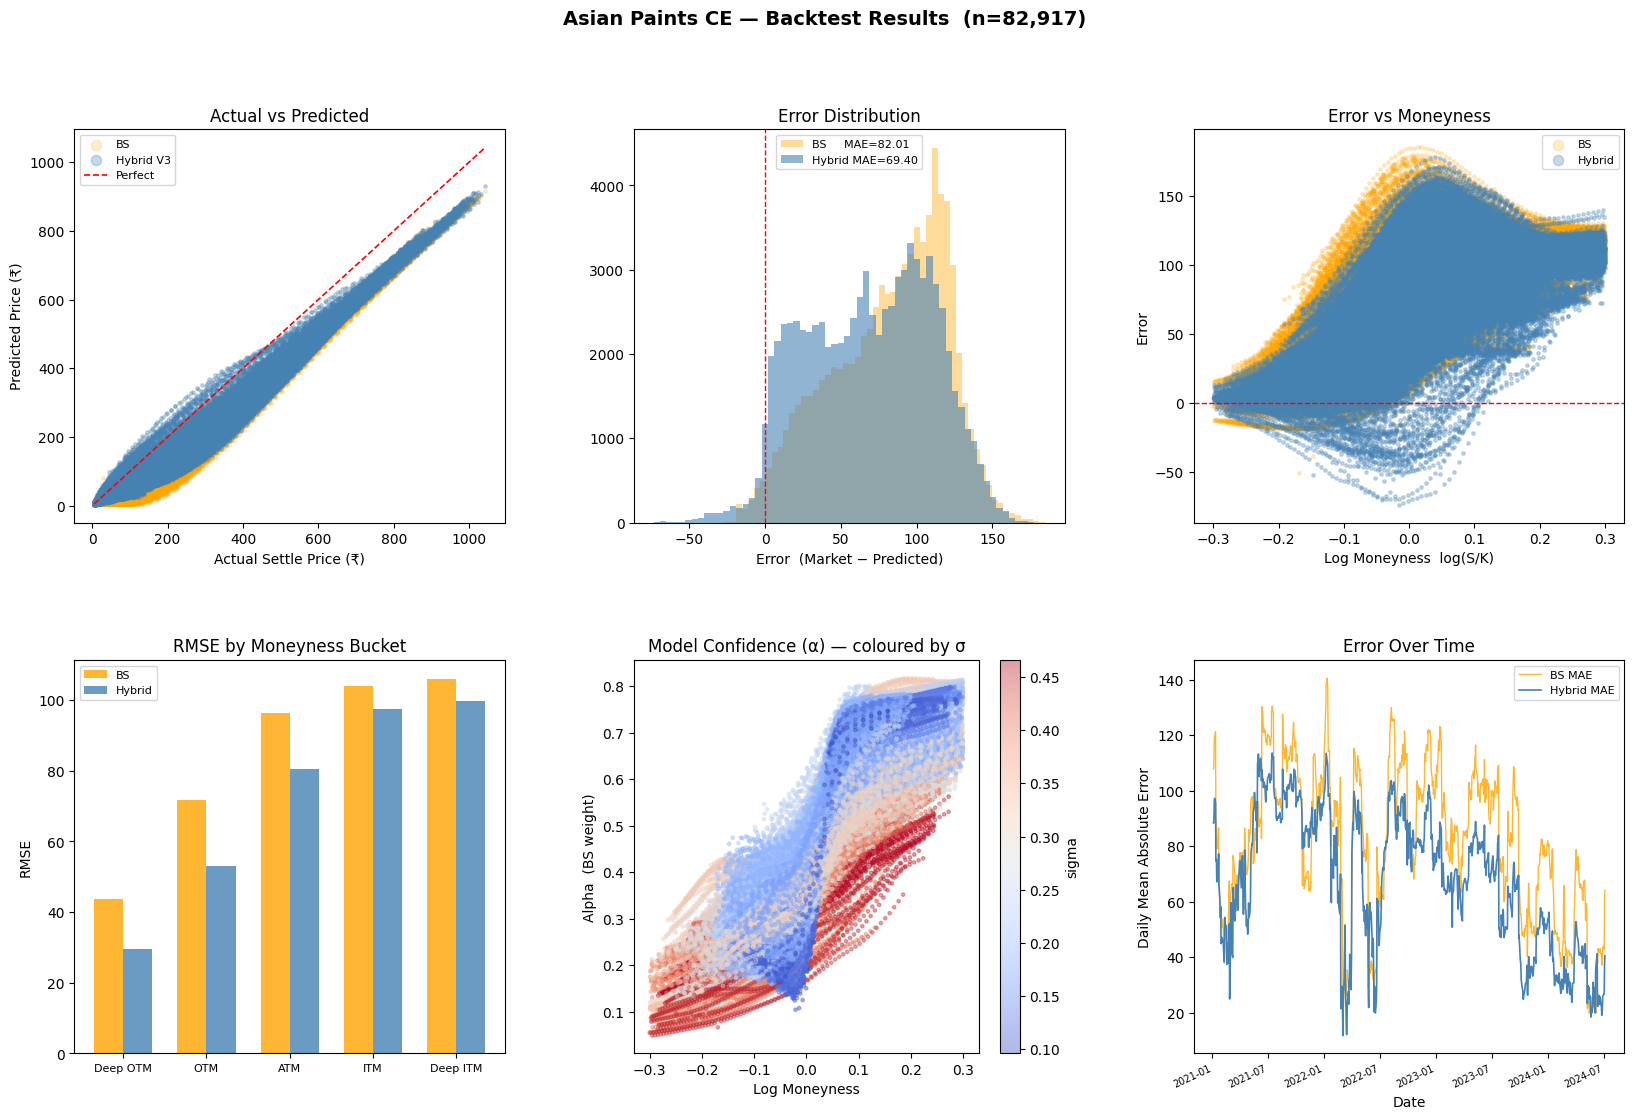

In [190]:
fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)
fig.suptitle(f'Asian Paints CE — Backtest Results  (n={len(df):,})', fontsize=14, fontweight='bold')

# 1. Actual vs Predicted
ax = fig.add_subplot(gs[0, 0])
ax.scatter(y, b, alpha=0.2, s=6, label='BS', color='orange')
ax.scatter(y, h, alpha=0.3, s=6, label='Hybrid V3', color='steelblue')
lim = [y.min(), y.max()]
ax.plot(lim, lim, 'r--', lw=1.2, label='Perfect')
ax.set_xlabel('Actual Settle Price (₹)')
ax.set_ylabel('Predicted Price (₹)')
ax.set_title('Actual vs Predicted')
ax.legend(markerscale=3, fontsize=8)

# 2. Error distribution
ax = fig.add_subplot(gs[0, 1])
ax.hist(df['bs_error'],     bins=60, alpha=0.4, label=f'BS     MAE={m_bs["MAE"]:.2f}', color='orange')
ax.hist(df['hybrid_error'], bins=60, alpha=0.6, label=f'Hybrid MAE={m_h["MAE"]:.2f}',  color='steelblue')
ax.axvline(0, color='red', linestyle='--', lw=1)
ax.set_xlabel('Error  (Market − Predicted)')
ax.set_title('Error Distribution')
ax.legend(fontsize=8)

# 3. Error vs Log Moneyness
ax = fig.add_subplot(gs[0, 2])
ax.scatter(df['log_moneyness'], df['bs_error'],     alpha=0.2, s=6, label='BS',     color='orange')
ax.scatter(df['log_moneyness'], df['hybrid_error'], alpha=0.3, s=6, label='Hybrid', color='steelblue')
ax.axhline(0, color='red', linestyle='--', lw=1)
ax.set_xlabel('Log Moneyness  log(S/K)')
ax.set_ylabel('Error')
ax.set_title('Error vs Moneyness')
ax.legend(markerscale=3, fontsize=8)

# 4. RMSE by moneyness bucket
ax = fig.add_subplot(gs[1, 0])
x = np.arange(len(bucket_df))
w = 0.35
ax.bar(x - w/2, bucket_df['bs_RMSE'],     w, label='BS',     color='orange',    alpha=0.8)
ax.bar(x + w/2, bucket_df['hybrid_RMSE'], w, label='Hybrid', color='steelblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(bucket_df.index, fontsize=8)
ax.set_ylabel('RMSE')
ax.set_title('RMSE by Moneyness Bucket')
ax.legend(fontsize=8)

# 5. Alpha (BS weight) vs Log Moneyness
ax = fig.add_subplot(gs[1, 1])
sc = ax.scatter(df['log_moneyness'], df['alpha'], c=df['sigma'],
                cmap='coolwarm', alpha=0.4, s=6)
plt.colorbar(sc, ax=ax, label='sigma')
ax.set_xlabel('Log Moneyness')
ax.set_ylabel('Alpha  (BS weight)')
ax.set_title('Model Confidence (α) — coloured by σ')

# 6. Daily MAE over time
ax = fig.add_subplot(gs[1, 2])
daily = df.groupby('Date').agg(
    hybrid_mae=('hybrid_error', lambda x: np.abs(x).mean()),
    bs_mae    =('bs_error',     lambda x: np.abs(x).mean()),
)
ax.plot(daily.index, daily['bs_mae'],     color='orange',    lw=1,   alpha=0.8, label='BS MAE')
ax.plot(daily.index, daily['hybrid_mae'], color='steelblue', lw=1.2, label='Hybrid MAE')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Mean Absolute Error')
ax.set_title('Error Over Time')
ax.legend(fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=25, ha='right', fontsize=7)

# plt.savefig('backtest_results.png', dpi=150, bbox_inches='tight')
plt.show()
# print('✓ Plot saved → backtest_results.png')

## 8 — Save Results

In [191]:
out_cols = [
    'Date', 'Expiry', 'S', 'K', 'T', 'sigma', 'vix',
    'log_moneyness', 'bucket',
    'bs_price', 'ml_price', 'hybrid_price', 'alpha', 'log_error',
    'Market_Price', 'hybrid_error', 'bs_error'
]
out_cols = [c for c in out_cols if c in df.columns]
# df[out_cols].to_csv(OUTPUT_CSV, index=False)
# print(f'✓ Results saved → {OUTPUT_CSV}  ({len(df):,} rows)')
df[out_cols].head(10)

,Date,Expiry,S,K,T,sigma,vix,log_moneyness,bucket,bs_price,ml_price,hybrid_price,alpha,log_error,Market_Price,hybrid_error,bs_error
0,2021-01-04,2021-03-25,2635.762451,1980.0,0.219178,0.200636,20.030001,0.286076,Deep ITM,678.898100,698.400519,685.419189,0.665625,0.028322,793.40,107.980811,114.501900
1,2021-01-04,2021-01-28,2635.762451,2440.0,0.065753,0.200636,20.030001,0.077174,ITM,207.978246,230.343684,218.091095,0.547836,0.102139,326.40,108.308905,118.421754
2,2021-01-04,2021-01-28,2635.762451,2420.0,0.065753,0.200636,20.030001,0.085405,ITM,226.853970,245.882821,235.180786,0.562410,0.080549,345.10,109.919214,118.246030
3,2021-01-04,2021-01-28,2635.762451,2400.0,0.065753,0.200636,20.030001,0.093704,ITM,246.027933,261.702454,252.750626,0.571107,0.061763,364.00,111.249374,117.972067
4,2021-01-04,2021-01-28,2635.762451,2380.0,0.065753,0.200636,20.030001,0.102072,Deep ITM,265.427565,277.134547,270.364319,0.578306,0.043161,383.15,112.785681,117.722435
5,2021-01-04,2021-01-28,2635.762451,2360.0,0.065753,0.200636,20.030001,0.110511,Deep ITM,284.993155,295.056679,289.141266,0.587811,0.034702,402.40,113.258734,117.406845
6,2021-01-04,2021-01-28,2635.762451,2340.0,0.065753,0.200636,20.030001,0.119022,Deep ITM,304.677273,314.083484,308.479523,0.595773,0.030406,421.85,113.370477,117.172727
7,2021-01-04,2021-01-28,2635.762451,2320.0,0.065753,0.200636,20.030001,0.127605,Deep ITM,324.443551,333.514317,328.038910,0.603631,0.027574,441.40,113.361090,116.956449
8,2021-01-04,2021-01-28,2635.762451,2300.0,0.065753,0.200636,20.030001,0.136263,Deep ITM,344.265058,353.265943,347.774780,0.610067,0.025809,461.05,113.275220,116.784942
9,2021-01-04,2021-01-28,2635.762451,2280.0,0.065753,0.200636,20.030001,0.144997,Deep ITM,364.122541,373.349696,367.667542,0.615807,0.025025,480.75,113.082458,116.627459
